# Dataset description
## Patrimony tax as percentage of total tax income
**Source**: DIAN

**Download**: [link](https://www.dian.gov.co/dian/cifras/Paginas/EstadisticasRecaudo.aspx)

# Code
## Imports

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [33]:
path = "./data/Estadisticas-de-recaudo-anual-por-tipo-de-impuesto-1970-2026.csv"

cols = [
    "Año",
    "ACTIVIDAD INTERNA",
    "Patrimonio /5",
    "Riqueza /6"
]

df = pd.read_csv(path, encoding="utf-8", usecols=cols)

## Clean data

In [34]:
df.drop(df.index[-1], inplace=True)
df_f = df[df["Año"].astype(int) > 2001]

df_f["Sum"] = df_f["Patrimonio /5"] + df_f["Riqueza /6"]
df_f["Share"] = (df_f["Sum"] / df_f["ACTIVIDAD INTERNA"]) * 100

## Plot

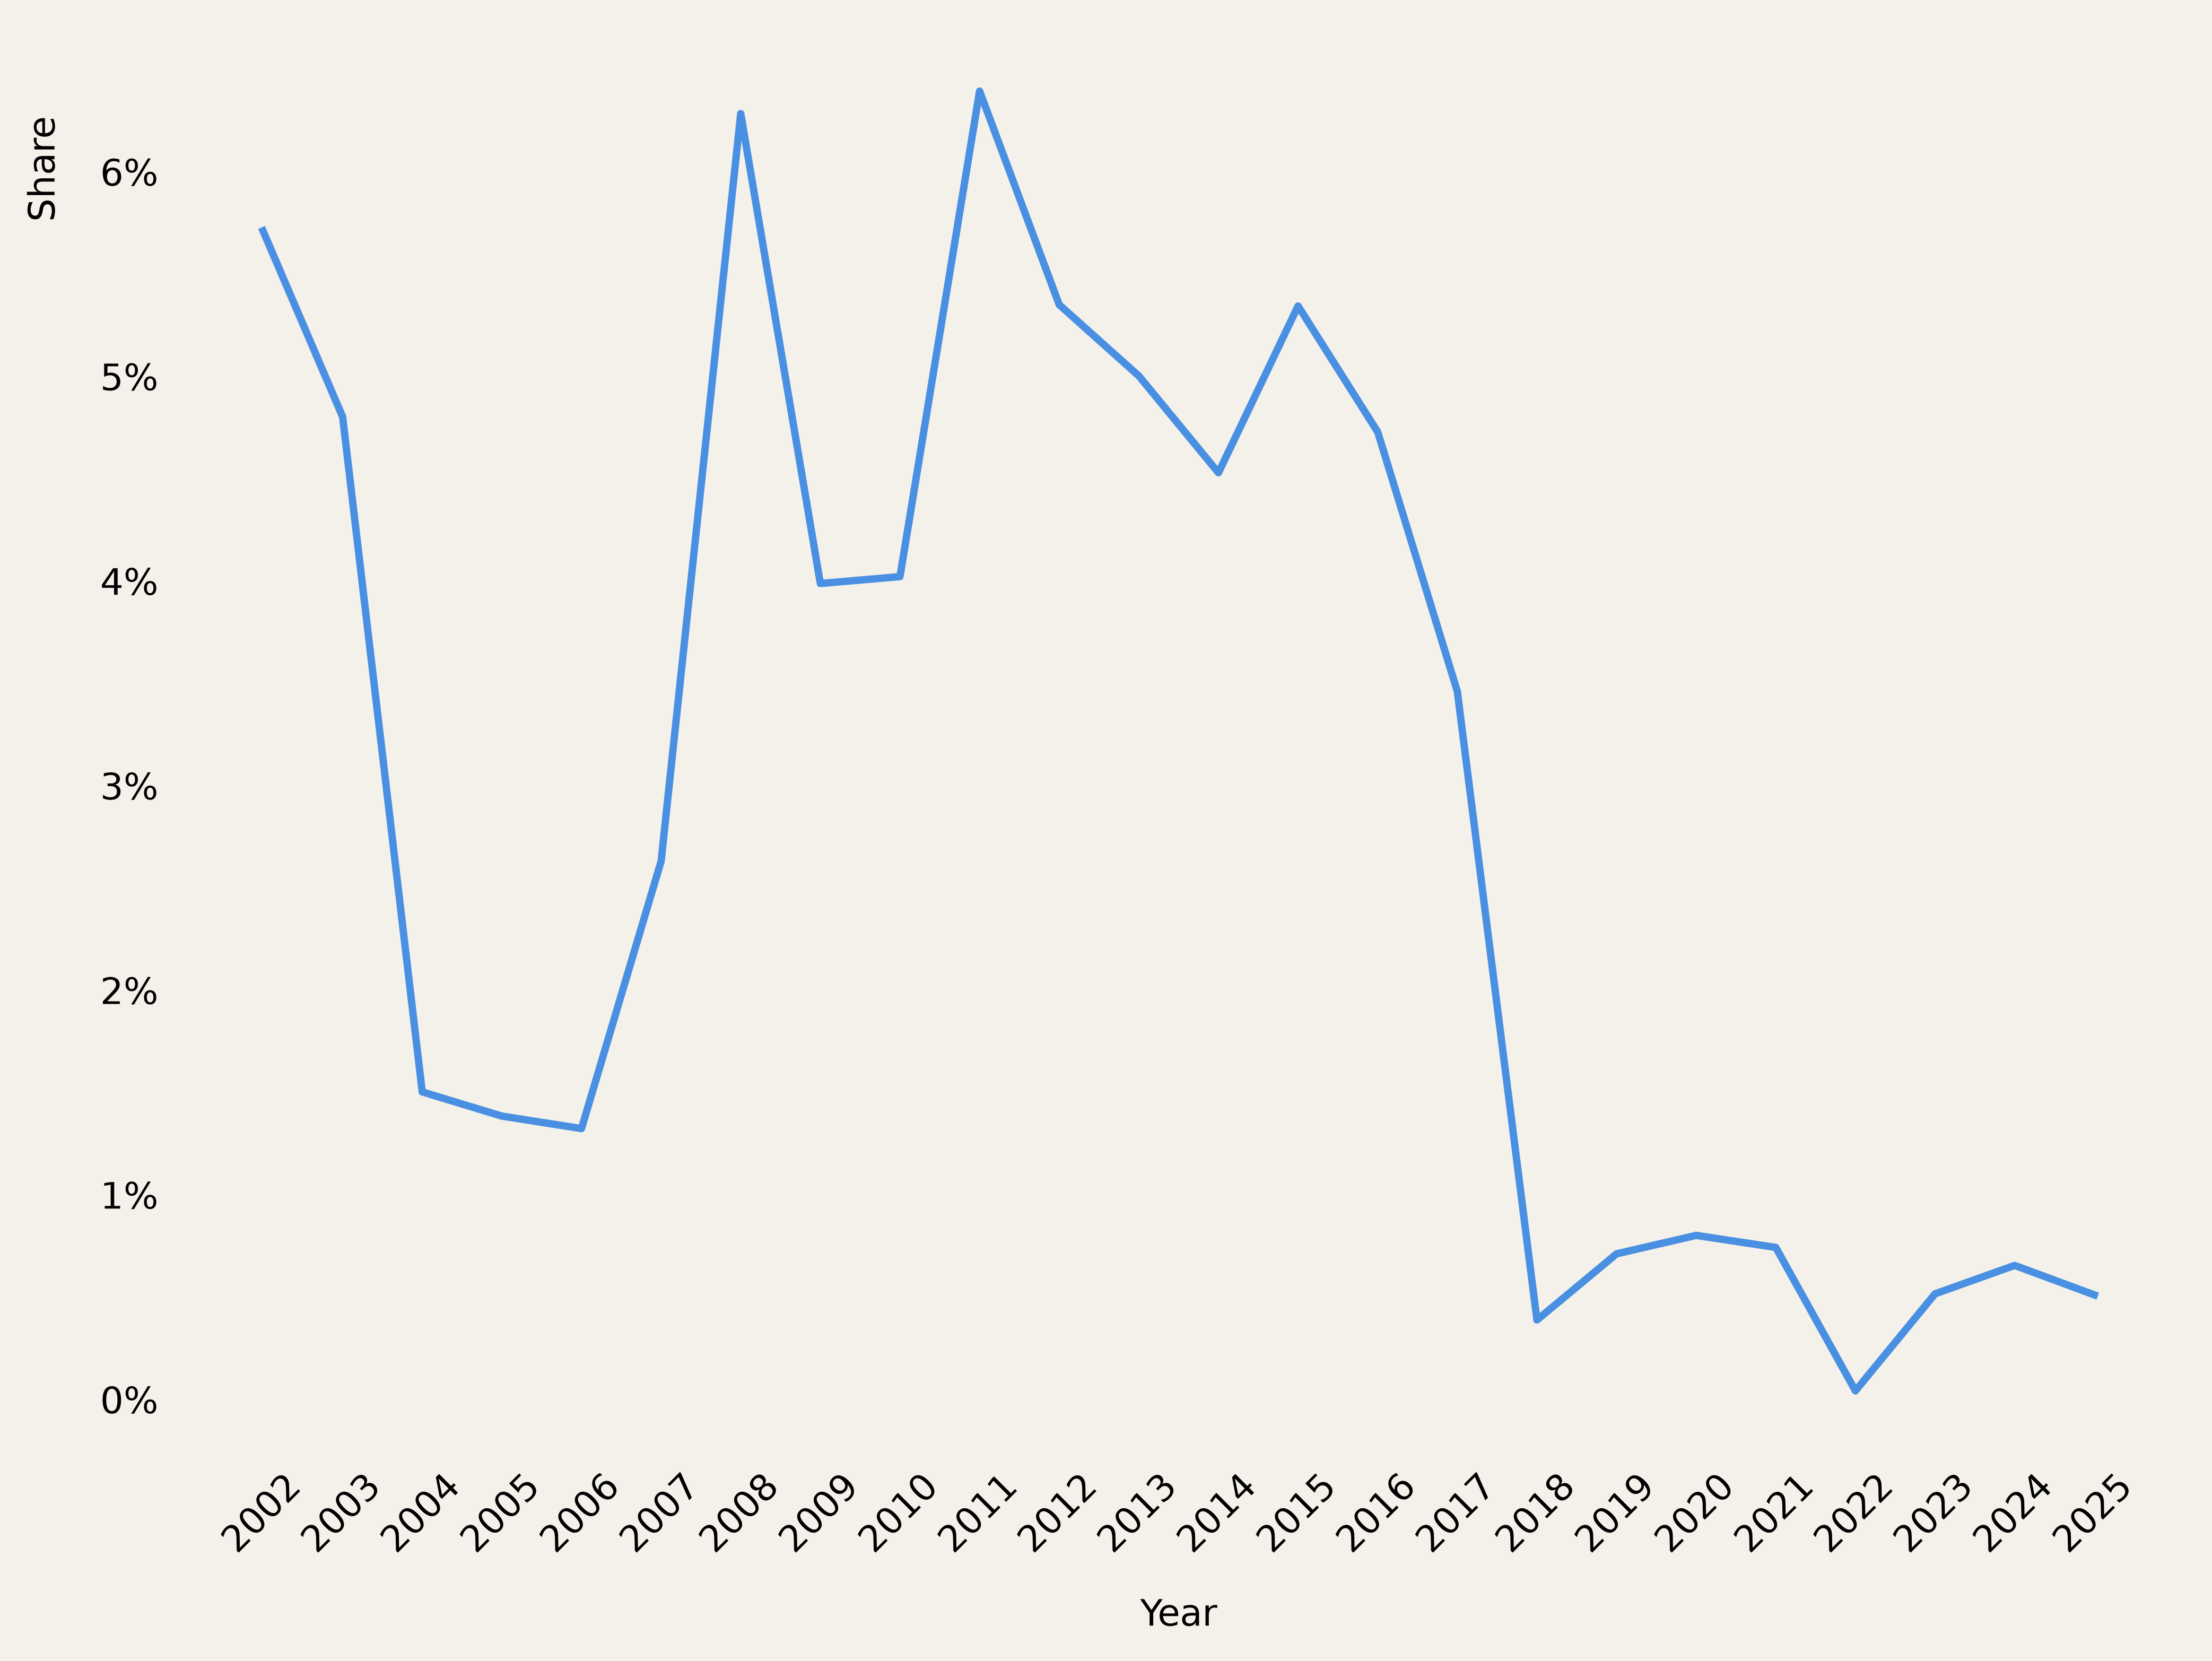

In [43]:
background = "#F4F1EA"
blue = "#4a90e2"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(df_f["Año"], df_f["Share"], linewidth=2, color=blue)

plt.xticks(df_f["Año"], rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.ylabel("Share", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.show()